In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import marimo as mo

# Global reset: clicking it restores every slider/switch to its default.
reset_all = mo.ui.refresh(label="Reset all controls")

mo.md(
    """
    # Lab 9 — SVM & PCA (interactive)

    **Drag any slider / flip any switch** — the chart and numbers below it update
    instantly. Each control sits *under* its own plot. Hit **Reset all controls** to
    restore every default.

    - **Part A (supervised):** SVM on Breast Cancer — class balancing + stratified
      k-fold CV + kernel comparison.
    - **Part B (unsupervised):** PCA on Wine — variance analysis, 2-D view, LDA
      extra credit.

    Every section has a one-line *what & why* note.
    """
)

_md()

In [2]:
mo.hstack([mo.md("**Reset everything to defaults:**"), reset_all])

_FlexContainerHtml()

In [3]:
_scaler_a = StandardScaler()
data = load_breast_cancer()
X_a = _scaler_a.fit_transform(data.data)
y_a = data.target
names_a = list(data.target_names)
mo.md(
    "**Part A — Load & standardize.** *Why: SVM is distance-based, so unscaled "
    "features would let large-magnitude columns dominate the margin.*  \n"
    f"Shape: {X_a.shape[0]} samples × {X_a.shape[1]} features · "
    f"classes {names_a} → counts {np.bincount(y_a).tolist()}"
)

_md()

_FlexContainerHtml()
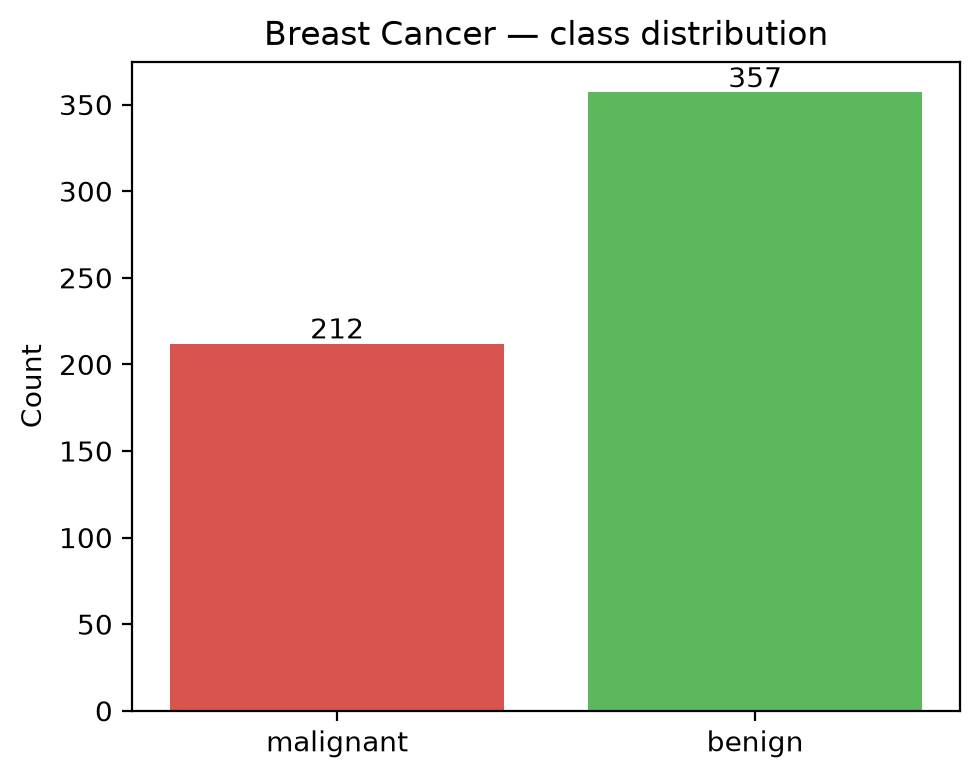

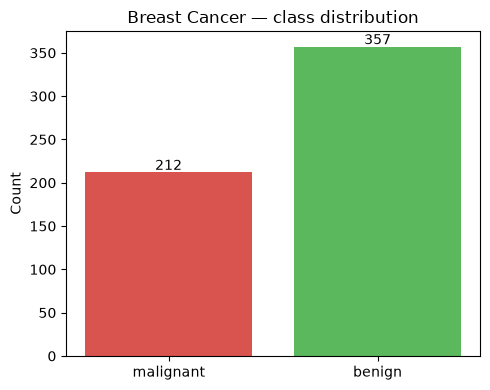

In [4]:
_c = np.bincount(y_a)
_f, _ax = plt.subplots(figsize=(5, 4))
_ax.bar(names_a, _c, color=["#d9534f", "#5cb85c"])
_ax.set_title("Breast Cancer — class distribution")
_ax.set_ylabel("Count")
for i, c in enumerate(_c):
    _ax.text(i, c + 3, str(int(c)), ha="center")
plt.tight_layout()
mo.vstack([
    mo.md(
        "**Class balance check.** *What: count each class. Why: it's mildly "
        "imbalanced (212 malignant vs 357 benign) — we correct that with "
        "`class_weight='balanced'` so the rarer malignant class isn't ignored.*"
    ),
    mo.as_html(_f),
])

In [5]:
test_size = mo.ui.slider(0.1, 0.4, 0.05, value=0.2, label="Test size (fraction)")

In [6]:
_Xtr, _Xte, _ytr, _yte = train_test_split(
    X_a, y_a, test_size=test_size.value, random_state=42, stratify=y_a
)
mo.vstack([
    mo.md(
        "**Train / test split.** *What: stratified 80/20 split (drag to change the "
        "fraction). Why: `stratify=y` keeps the class ratio identical in train and "
        "test, and `random_state=42` makes results reproducible.*"
    ),
    mo.md(
        f"Train **{_Xtr.shape[0]}** · Test **{_Xte.shape[0]}** · "
        f"test class counts {np.bincount(_yte).tolist()}"
    ),
    test_size,
])

_FlexContainerHtml()

In [7]:
balance = mo.ui.switch(value=True, label="class_weight='balanced'")

In [8]:
_cw = "balanced" if balance.value else None
_Xtr, _Xte, _ytr, _yte = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)
_clf = SVC(kernel="linear", class_weight=_cw, random_state=42).fit(_Xtr, _ytr)
_yp = _clf.predict(_Xte)
_cm = confusion_matrix(_yte, _yp)
mo.vstack([
    mo.md(
        "**Linear SVM — baseline vs balanced.** *What: toggle class weighting. Why: "
        "`class_weight='balanced'` reweights the loss so mistakes on the minority "
        "class cost more, lifting its recall/F1.*"
    ),
    mo.md(
        f"| Metric | Value |\n|---|---|\n"
        f"| Accuracy  | {accuracy_score(_yte, _yp):.4f} |\n"
        f"| Precision | {precision_score(_yte, _yp):.4f} |\n"
        f"| Recall    | {recall_score(_yte, _yp):.4f} |\n"
        f"| F1 Score  | {f1_score(_yte, _yp):.4f} |\n\n"
        f"Confusion matrix (rows=true, cols=pred): `{_cm.tolist()}`\n\n"
        "<details><summary>Report</summary>\n\n```\n"
        + classification_report(_yte, _yp, target_names=names_a)
        + "```\n</details>"
    ),
    balance,
])

Metric,Value
Accuracy,0.9561
Precision,0.9855
Recall,0.9444
F1 Score,0.9645


In [9]:
folds_c = mo.ui.slider(3, 10, 1, value=5, label="CV folds (k)")

In [10]:
_Xtr, _Xte, _ytr, _yte = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)
_cv = StratifiedKFold(n_splits=folds_c.value, shuffle=True, random_state=42)
_gs = GridSearchCV(
    SVC(kernel="linear", class_weight="balanced", random_state=42),
    {"C": np.logspace(-3, 3, 13)}, cv=_cv, scoring="f1", n_jobs=-1,
).fit(_Xtr, _ytr)
best_C = _gs.best_params_["C"]
mo.vstack([
    mo.md(
        "**Tune C with GridSearchCV.** *What: search C over a log range using "
        "stratified k-fold CV, pick the best CV F1. Why: C trades margin width vs "
        "misclassification tolerance — CV finds the generalizable value.*"
    ),
    mo.md(
        f"**Best C = `{best_C:.4f}`** · mean CV F1 = `{_gs.best_score_:.4f}` "
        f"(over {folds_c.value}-fold stratified CV)"
    ),
    folds_c,
])

_FlexContainerHtml()

In [11]:
_Xtr, _Xte, _ytr, _yte = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)
_m = SVC(kernel="linear", C=best_C, class_weight="balanced", random_state=42).fit(_Xtr, _ytr)
_yp = _m.predict(_Xte)
mo.md(
    f"**Tuned linear SVM (C = `{best_C:.4f}`).** *What: refit with the tuned C. "
    f"Why: confirms the chosen hyperparameter holds on the held-out test set.*\n\n"
    f"| Metric | Value |\n|---|---|\n"
    f"| Accuracy  | {accuracy_score(_yte, _yp):.4f} |\n"
    f"| Precision | {precision_score(_yte, _yp):.4f} |\n"
    f"| Recall    | {recall_score(_yte, _yp):.4f} |\n"
    f"| F1 Score  | {f1_score(_yte, _yp):.4f} |\n\n"
    f"Confusion matrix: `{confusion_matrix(_yte, _yp).tolist()}`"
)

Metric,Value
Accuracy,0.9737
Precision,0.9859
Recall,0.9722
F1 Score,0.9790


In [12]:
_m = SVC(kernel="linear", C=best_C, class_weight="balanced", random_state=42)
_cv = StratifiedKFold(5, shuffle=True, random_state=42)
_rows = []
for _s in ["accuracy", "f1", "precision", "recall"]:
    _v = cross_val_score(_m, X_a, y_a, cv=_cv, scoring=_s)
    _rows.append(f"| {_s} | {_v.mean():.4f} ± {_v.std():.4f} |")
mo.md(
    "**Stratified k-fold CV (full data).** *What: 5-fold CV reporting mean ± std. "
    "Why: a single split can mislead; CV gives a stable generalization estimate.*\n\n"
    "| Score | Mean ± Std |\n|---|---|\n" + "\n".join(_rows)
)

Score,Mean ± Std
accuracy,0.9772 ± 0.0089
f1,0.9820 ± 0.0069
precision,0.9757 ± 0.0195
recall,0.9888 ± 0.0162


In [13]:
folds_k = mo.ui.slider(3, 10, 1, value=5, label="CV folds (k)")

In [14]:
_Xtr, _Xte, _ytr, _yte = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)
_cv = StratifiedKFold(n_splits=folds_k.value, shuffle=True, random_state=42)
_res = {}
for _k in ["linear", "rbf", "poly"]:
    _clf = SVC(kernel=_k, class_weight="balanced", random_state=42)
    _cvf1 = cross_val_score(_clf, _Xtr, _ytr, cv=_cv, scoring="f1").mean()
    _clf.fit(_Xtr, _ytr)
    _yp = _clf.predict(_Xte)
    _res[_k] = (_cvf1, accuracy_score(_yte, _yp), f1_score(_yte, _yp))
_win = max(_res, key=lambda k: _res[k][0])
_rows = [f"| {k} | {_res[k][0]:.4f} | {_res[k][1]:.4f} | {_res[k][2]:.4f} |"
         for k in _res]
mo.vstack([
    mo.md(
        "**Kernel comparison.** *What: compare linear / rbf / poly by CV F1. Why: "
        "different kernels reshape the decision boundary — rbf usually wins on "
        "well-scaled data.*"
    ),
    mo.md(
        "| Kernel | CV F1 | Test Acc | Test F1 |\n|---|---|---|---|\n"
        + "\n".join(_rows)
        + f"\n\n**Winner (CV F1):** `{_win}`"
    ),
    folds_k,
])

Kernel,CV F1,Test Acc,Test F1
linear,0.9755,0.9561,0.9645
rbf,0.9807,0.9649,0.9718
poly,0.9409,0.9561,0.9664


In [15]:
_c = np.bincount(y_a)
mo.md(
    f"**Part A observations.** *What/why summary:* standardized 30 features; mild "
    f"imbalance ({int(_c[0])} vs {int(_c[1])}) handled via `class_weight='balanced'`; "
    f"best C = `{best_C:.4f}` from stratified-CV grid search; 5-fold CV shows stable "
    f"generalization; kernel chosen by CV F1. All kernels score high because the "
    f"classes separate well in standardized space."
)

_md()

In [16]:
_scaler_w = StandardScaler()
_wine = load_wine()
X_w = _scaler_w.fit_transform(_wine.data)
y_w = _wine.target
feats_w = list(_wine.feature_names)
targs_w = list(_wine.target_names)
mo.md(
    "**Part B — Load & standardize Wine.** *Why: PCA is variance-based and "
    "scale-sensitive, so we standardize first.*  \n"
    f"Shape: {X_w.shape[0]} samples × {X_w.shape[1]} features · "
    f"classes {targs_w} → counts {np.bincount(y_w).tolist()}"
)

_md()

In [17]:
n_pcs = mo.ui.slider(2, 13, 1, value=2, label="Number of principal components")

Component,Variance explained
PC1,0.3620 (36.20%)
PC2,0.1921 (19.21%)

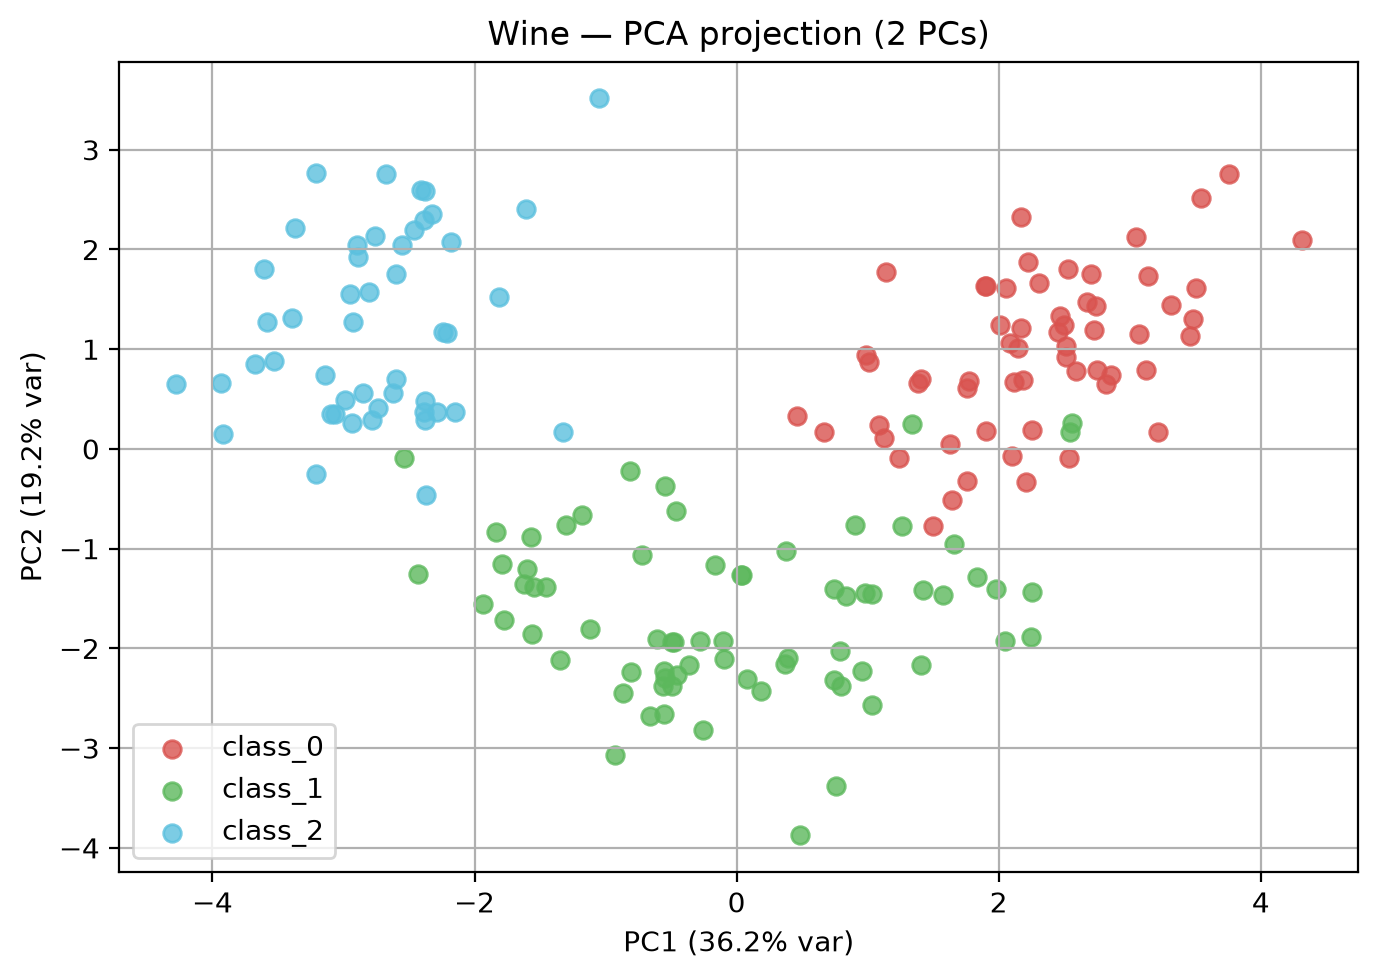

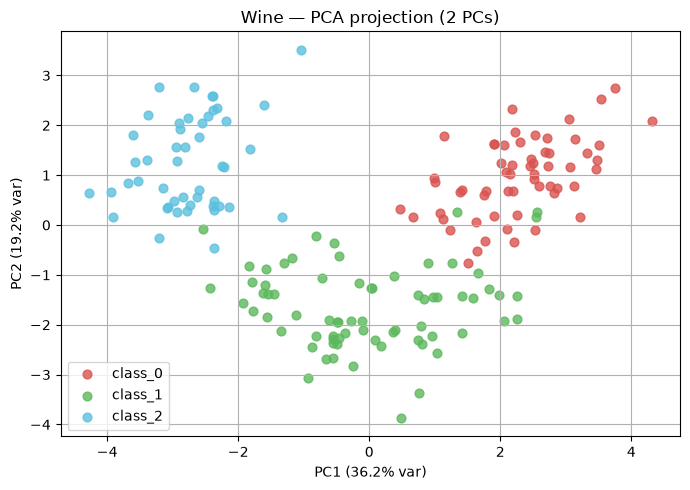

In [18]:
pca = PCA(n_components=n_pcs.value, random_state=42).fit(X_w)
_proj = pca.transform(X_w)
ratio = pca.explained_variance_ratio_

_f, _ax = plt.subplots(figsize=(7, 5))
_cols = ["#d9534f", "#5cb85c", "#5bc0de"]
for _i, _n in enumerate(targs_w):
    _m = y_w == _i
    _ax.scatter(_proj[_m, 0], _proj[_m, 1], c=_cols[_i], label=_n, s=40, alpha=0.8)
_ax.set_xlabel(f"PC1 ({ratio[0]*100:.1f}% var)")
_ax.set_ylabel(f"PC2 ({ratio[1]*100:.1f}% var)")
_ax.set_title(f"Wine — PCA projection ({n_pcs.value} PCs)")
_ax.legend(); _ax.grid(True)
plt.tight_layout()

_rows = [f"| PC{i+1} | {r:.4f} ({r*100:.2f}%) |" for i, r in enumerate(ratio)]
mo.vstack([
    mo.md(
        "**PCA projection + explained variance.** *What: drag to keep N components; "
        "we show the 2-D view and each PC's variance share. Why: PCA keeps the "
        "directions of maximum variance, so a few PCs capture most of the signal.*"
    ),
    mo.md(
        f"**Explained variance ratio** (keeping {n_pcs.value} PCs):\n\n"
        "| Component | Variance explained |\n|---|---|\n" + "\n".join(_rows)
        + f"\n\n**Total retained:** `{ratio.sum()*100:.2f}%`"
    ),
    mo.as_html(_f),
    n_pcs,
])

_FlexContainerHtml()
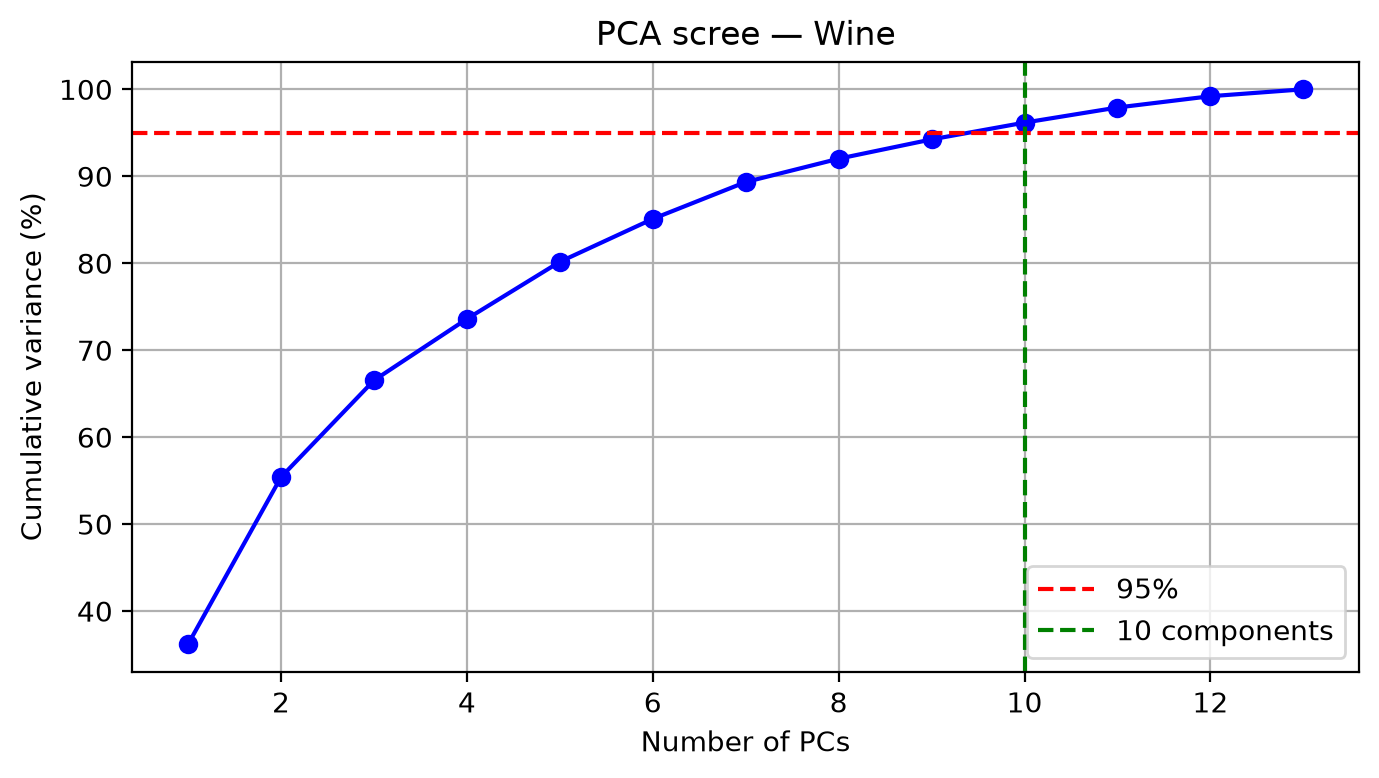

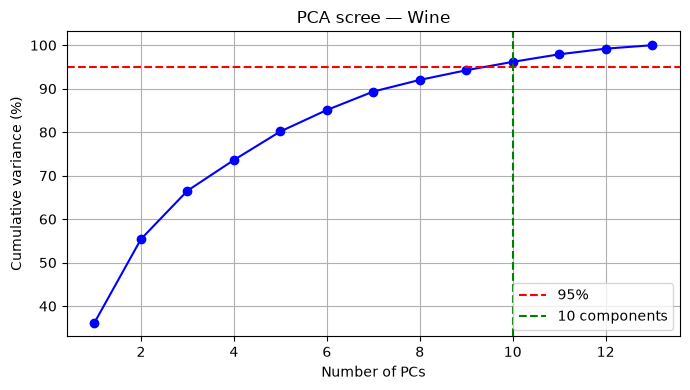

In [19]:
_full = PCA(random_state=42).fit(X_w)
_cum = np.cumsum(_full.explained_variance_ratio_)
_n95 = int(np.argmax(_cum >= 0.95) + 1)
_f, _ax = plt.subplots(figsize=(7, 4))
_ax.plot(range(1, len(_cum) + 1), _cum * 100, "bo-")
_ax.axhline(95, color="r", linestyle="--", label="95%")
_ax.axvline(_n95, color="g", linestyle="--", label=f"{_n95} components")
_ax.set_xlabel("Number of PCs"); _ax.set_ylabel("Cumulative variance (%)")
_ax.set_title("PCA scree — Wine"); _ax.legend(); _ax.grid(True)
plt.tight_layout()
mo.vstack([
    mo.md(
        "**How many PCs for ≥ 95% variance?** *What: fit full PCA, read the "
        "cumulative curve. Why: it's the compression sweet spot — few components, "
        f"almost all information. Answer: **{_n95}** of 13.*"
    ),
    mo.as_html(_f),
])

In [20]:
mo.md(
    "**Interpreting PC1 & PC2 (loadings).** *What: show each feature's weight on a "
    "PC. Why: large |weights| reveal which original features drive that axis — helps "
    "explain the reduced space.*"
)
_blocks = []
for _pc in range(pca.components_.shape[0]):
    _order = np.argsort(-np.abs(pca.components_[_pc]))
    _top = ", ".join(f"{feats_w[i]} ({pca.components_[_pc][i]:+.2f})"
                     for i in _order[:5])
    _blocks.append(f"**PC{_pc+1}** top loadings: {_top}")
mo.md("\n\n".join(_blocks))

_md()

**Original vs transformed (PCA).** *Why this matters:* we trade a little
information for speed and a visualizable 2-D space.

| Aspect | Original (13-D) | PCA (2-D) |
|---|---|---|
| # features | 13 | 2 |
| Information | 100% | ~55% retained |
| Efficiency | slower | faster |
| Separability | full | mostly kept |
| Interpretability | per-feature | mixed combos |

**PCA pros:** decorrelates, denoises, compresses, speeds models, enables 2-D
plots. **Cons:** loses variance, components are less interpretable, scale-
sensitive, unsupervised (ignores labels). **Uses:** preprocessing, denoising,
visualization, eigenfaces, factor analysis.

In [21]:
show_lda = mo.ui.switch(value=True, label="Show LDA projection")

_FlexContainerHtml()
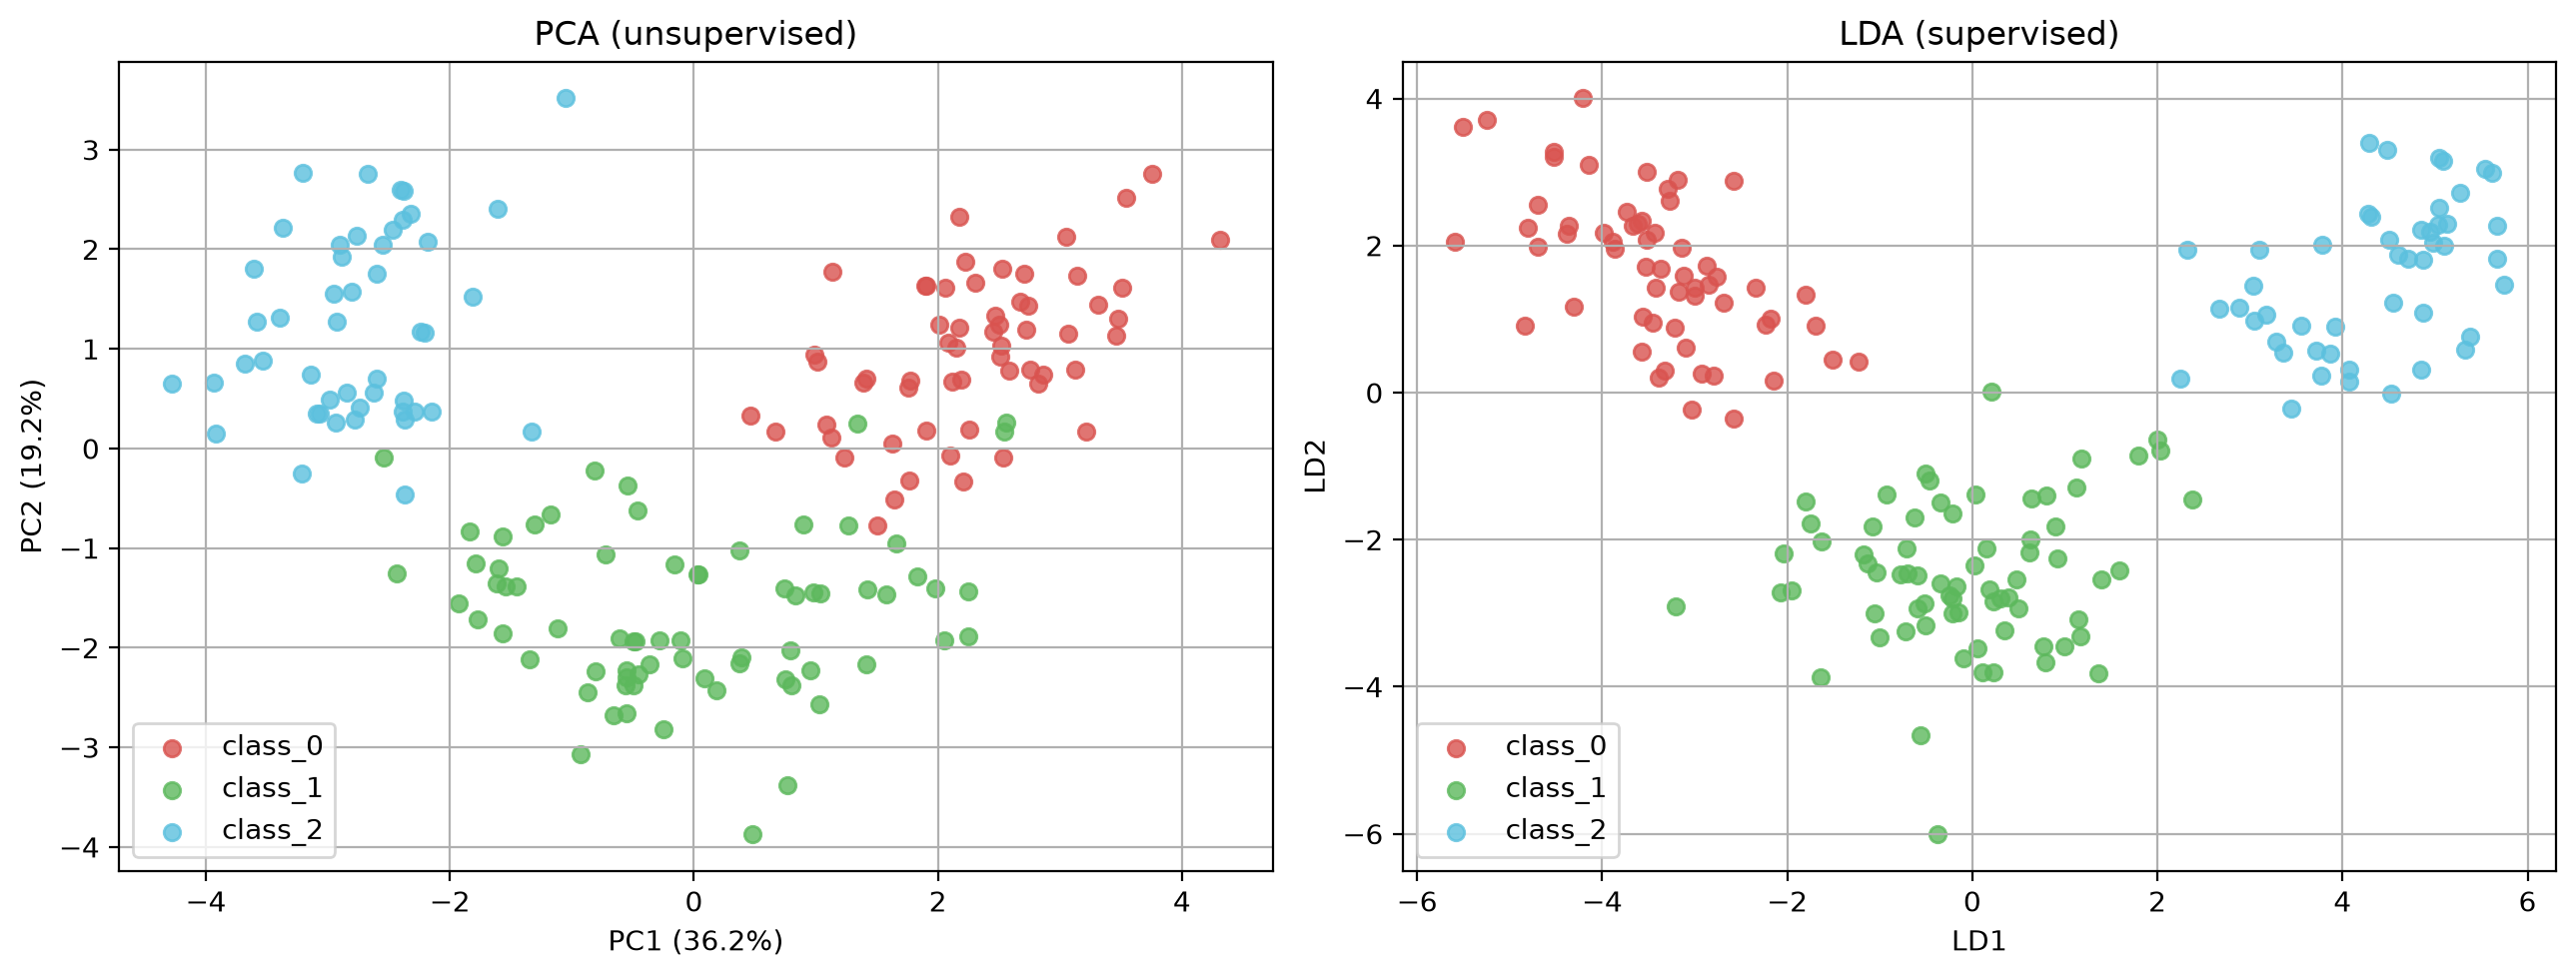

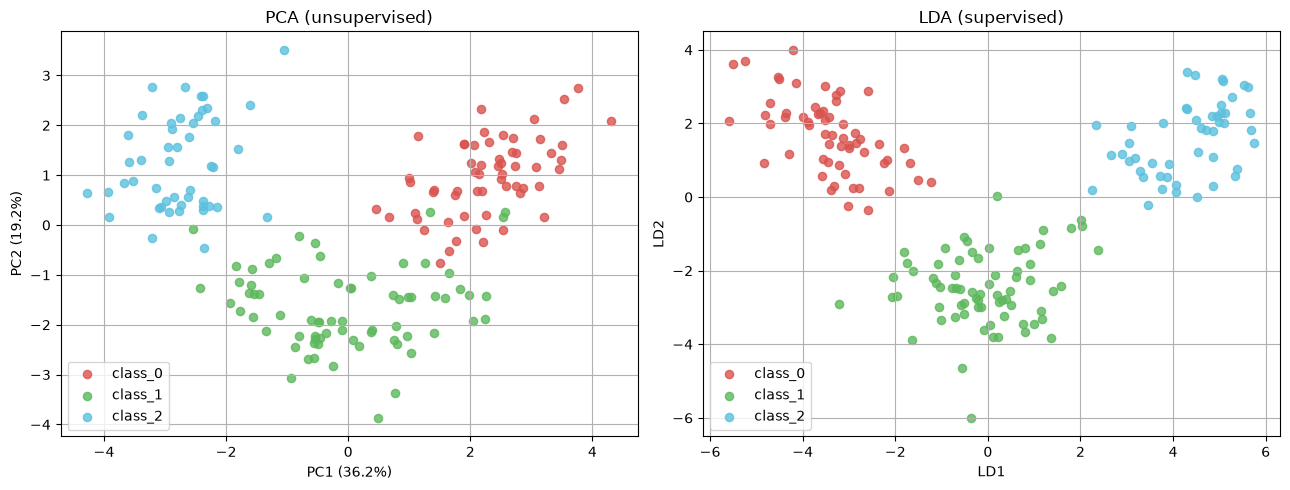

In [22]:
_cols = ["#d9534f", "#5cb85c", "#5bc0de"]
_pca2 = PCA(n_components=2, random_state=42).fit(X_w)
_Xp = _pca2.transform(X_w)

if show_lda.value:
    _lda = LinearDiscriminantAnalysis(n_components=2).fit(X_w, y_w)
    _Xl = _lda.transform(X_w)
    _f, _ax = plt.subplots(1, 2, figsize=(13, 5))
else:
    _f, _ax = plt.subplots(1, 1, figsize=(7, 5))
    _ax = [_ax]

for _i, _n in enumerate(targs_w):
    _m = y_w == _i
    _ax[0].scatter(_Xp[_m, 0], _Xp[_m, 1], c=_cols[_i], label=_n, s=35, alpha=0.8)
_ax[0].set_title("PCA (unsupervised)")
_ax[0].set_xlabel(f"PC1 ({ratio[0]*100:.1f}%)")
_ax[0].set_ylabel(f"PC2 ({ratio[1]*100:.1f}%)")
_ax[0].legend(); _ax[0].grid(True)

_extra = ""
if show_lda.value:
    for _i, _n in enumerate(targs_w):
        _m = y_w == _i
        _ax[1].scatter(_Xl[_m, 0], _Xl[_m, 1], c=_cols[_i], label=_n, s=35, alpha=0.8)
    _ax[1].set_title("LDA (supervised)")
    _ax[1].set_xlabel("LD1"); _ax[1].set_ylabel("LD2")
    _ax[1].legend(); _ax[1].grid(True)
    plt.tight_layout()
    _extra = (
        "\n\n**LDA explained variance:** "
        f"`{_lda.explained_variance_ratio_.round(4).tolist()}` "
        f"(total {_lda.explained_variance_ratio_.sum()*100:.2f}%). LDA separates the "
        "3 cultivars more cleanly than PCA because it uses labels, but is limited to "
        "C-1 = 2 components for 3 classes."
    )

mo.vstack([
    mo.md(
        "**Extra credit — LDA.** *What: supervised alternative to PCA, reduced to 2 "
        "discriminants. Why: LDA uses labels to maximize class separation, so "
        "clusters look tighter than PCA — but it needs labels and is capped at C-1 "
        "components.*"
    ),
    mo.as_html(_f),
    show_lda,
    mo.md(_extra),
])

In [23]:
_c = np.bincount(y_a)
mo.md(
    f"""
    ## Conclusions

    1. **SVM (supervised):** Linear SVM with `class_weight='balanced'` handled the
       mild imbalance ({int(_c[0])} vs {int(_c[1])}); stratified k-fold CV confirmed
       stable generalization; kernel chosen by CV F1.
    2. **PCA (unsupervised):** Reduced Wine 13 → 2 keeping ~55% variance; only **10**
       components needed for ≥ 95% variance — strong compression.
    3. **Supervised vs unsupervised:** SVM uses labels to classify; PCA ignores labels
       and only compresses variance. LDA (extra credit) uses labels and yields tighter
       class clusters than PCA in 2-D, at the cost of needing labels and fewer components.

    *Tuned C (Part A) = `{best_C:.4f}`.*
    """
)

_md()